In [1]:
import os

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
from venn import venn

from itertools import combinations

In [2]:
model = 'condition'

In [3]:
folder = "./results/contrasts/"
list_df = []
for file in os.listdir(folder):
    if model in file:
        df = pd.read_csv(f'{folder}/{file}',sep=';')
        file_name = file[:-4]
        split = file_name.split("_")
        contrast = "_".join(split[1:])
        df['contrast'] = contrast
        list_df+=[df]

In [4]:
concat = pd.concat(list_df)

In [5]:
contrast_list = concat['contrast'].unique().tolist()
n_contrast = len(contrast_list)

In [6]:
contrast_list

['Trained_Young_VS_Control_Young',
 'Control_Old_VS_Control_Young',
 'Trained_Old_VS_Control_Old',
 'Trained_Old_VS_Trained_Young']

In [7]:
padj_threshold = 0.05
log2fc_threshold = np.log2(1.5)

## All contrasts

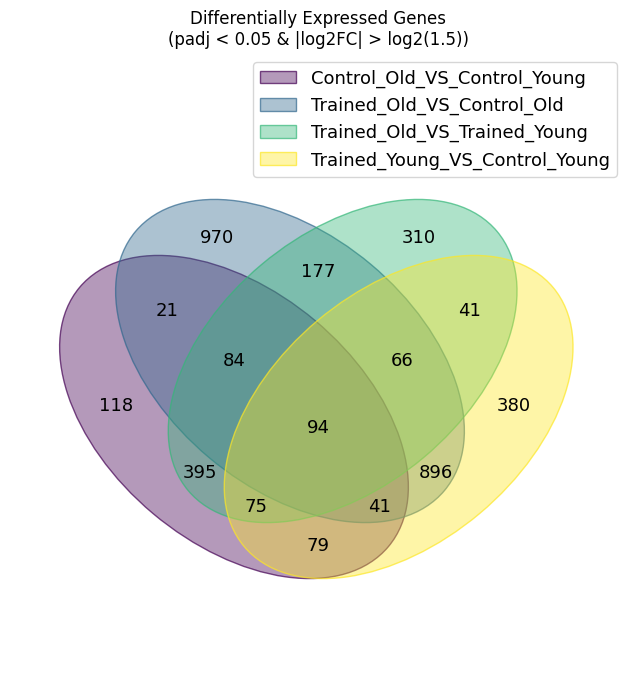

In [9]:
# Filter DE genes
de_df = concat[
    (concat["padj"] < padj_threshold) &
    (concat["log2FoldChange"].abs() > log2fc_threshold)
]

# Build gene sets per contrast
gene_sets = {
    contrast: set(sub["gene_name"])
    for contrast, sub in de_df.groupby("contrast")
}

# Optional: keep only 4 contrasts (required for a 4-way Venn)
# Adjust this selection if needed
selected_contrasts = list(gene_sets.keys())[:n_contrast]
gene_sets_total = {k: gene_sets[k] for k in selected_contrasts}

# Plot Venn diagram
#plt.figure(figsize=(8, 8))
venn(gene_sets_total)
plt.title("Differentially Expressed Genes\n(padj < 0.05 & |log2FC| > log2(1.5))")
plt.show()


## Pairwise compareason

In [20]:
def get_pairwise_contrasts(contrast_list):
    return list(combinations(contrast_list, 2))

In [21]:
pairs = get_pairwise_contrasts(contrast_list)

In [22]:
pairs

[('Trained_Young_VS_Control_Young', 'Control_Old_VS_Control_Young'),
 ('Trained_Young_VS_Control_Young', 'Trained_Old_VS_Control_Old'),
 ('Trained_Young_VS_Control_Young', 'Trained_Old_VS_Trained_Young'),
 ('Control_Old_VS_Control_Young', 'Trained_Old_VS_Control_Old'),
 ('Control_Old_VS_Control_Young', 'Trained_Old_VS_Trained_Young'),
 ('Trained_Old_VS_Control_Old', 'Trained_Old_VS_Trained_Young')]

In [29]:
from itertools import combinations
import matplotlib.pyplot as plt
from venn import venn


def plot_venn_deg(
    df,
    contrasts,
    padj_threshold=0.05,
    log2fc_threshold=np.log2(2),
    mode="abs",  # "abs", "up", "down"
    title=None,
    figsize=(6, 6),
    save=None
):
    # --------------------------------------------------
    # 1. Filter DEG
    # --------------------------------------------------
    de = df[df["contrast"].isin(contrasts)]
    de = de[de["padj"] < padj_threshold]

    if mode == "abs":
        de = de[de["log2FoldChange"].abs() > log2fc_threshold]
    elif mode == "up":
        de = de[de["log2FoldChange"] > log2fc_threshold]
    elif mode == "down":
        de = de[de["log2FoldChange"] < -log2fc_threshold]
    else:
        raise ValueError("mode must be 'abs', 'up', or 'down'")

    if de.empty:
        print("No DE genes for given parameters.")
        return None

    # --------------------------------------------------
    # 2. Gene sets
    # --------------------------------------------------
    gene_sets = {
        c: set(de.loc[de["contrast"] == c, "gene_name"])
        for c in contrasts
    }

    # Remove empty sets (important for venn stability)
    gene_sets = {k: v for k, v in gene_sets.items() if len(v) > 0}

    if len(gene_sets) < 2:
        print("Not enough non-empty gene sets to plot Venn.")
        return None

    # --------------------------------------------------
    # 3. Plot
    # --------------------------------------------------
    plt.figure(figsize=figsize)
    venn(gene_sets)

    if title is None:
        title = f"DE genes ({mode})\npadj<{padj_threshold}, log2FC>{log2fc_threshold}"

    plt.title(title)

    if save:
        os.makedirs("./results/venn/", exist_ok=True)
        plt.savefig(f"./results/venn/{save}.png", dpi=300)

    plt.show()

In [32]:
concat

,gene_id,gene_name,_normed_means,non_zero,_MoM_dispersions,genewise_dispersions,_genewise_converged,fitted_dispersions,MAP_dispersions,_MAP_converged,...,refitted,_pvalue_cooks_outlier,vst_genewise_dispersions,baseMean,log2FoldChange,lfcSE,stat,pvalue,padj,contrast
0,ENSMUSG00000000001,Gnai3,6614.435806,True,4.969545e-03,2.821676e-03,True,0.010444,0.003444,True,...,False,False,5.004018e-03,6614.435806,0.071631,0.061170,1.171015,0.241593,0.376807,Trained_Young_VS_Control_Young
1,ENSMUSG00000000028,Cdc45,2677.765983,True,6.044206e-03,3.318042e-03,True,0.011192,0.004050,True,...,False,False,6.035815e-03,2677.765983,-0.053403,0.067647,-0.789444,0.429853,0.566526,Trained_Young_VS_Control_Young
2,ENSMUSG00000000031,H19,3.545939,True,1.000000e-08,1.000000e-08,True,0.959479,0.201194,True,...,False,False,1.000000e-08,3.545939,0.756689,0.707121,1.070099,0.284575,NaN,Trained_Young_VS_Control_Young
3,ENSMUSG00000000037,Scml2,506.453130,True,4.197109e-02,1.530790e-02,True,0.016583,0.015505,True,...,False,False,3.996576e-02,506.453130,-0.430428,0.134007,-3.211980,0.001318,0.010214,Trained_Young_VS_Control_Young
4,ENSMUSG00000000056,Narf,2833.805782,True,5.900942e-02,2.755707e-02,True,0.011123,0.024601,True,...,False,False,5.193093e-02,2833.805782,-0.379488,0.161121,-2.355297,0.018508,0.061284,Trained_Young_VS_Control_Young
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
22284,ENSMUSG00002076556,Gm56424,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,16.984368,-0.941936,1.012747,-0.930080,0.352330,0.598132,Trained_Old_VS_Trained_Young
22285,ENSMUSG00002076601,Scarna13,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,0.616981,-1.220922,2.270797,-0.537662,0.590810,NaN,Trained_Old_VS_Trained_Young
22286,ENSMUSG00002076665,Gm54427,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,0.485802,-2.680900,2.929379,-0.915177,0.360099,NaN,Trained_Old_VS_Trained_Young
22287,ENSMUSG00002076675,Gm56334,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,0.729818,0.794537,1.723314,0.461052,0.644761,NaN,Trained_Old_VS_Trained_Young


<Figure size 600x600 with 0 Axes>

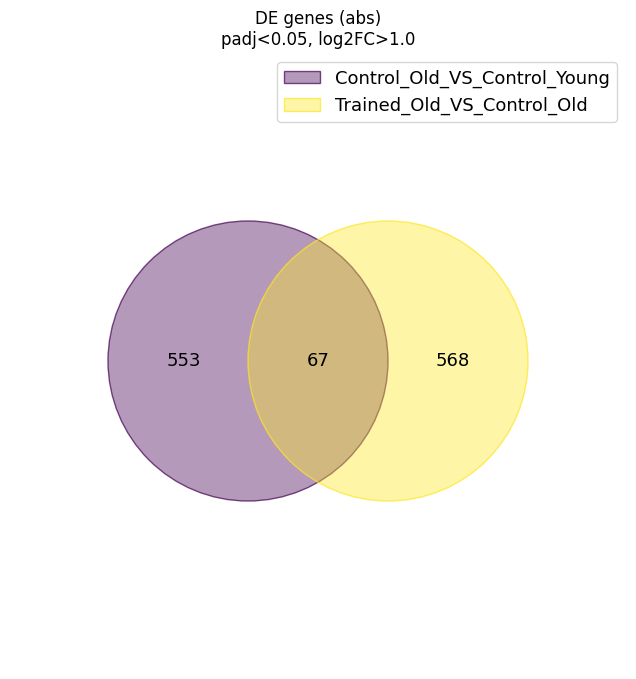

In [33]:
plot_venn_deg(concat,contrasts=pairs[3])

<Figure size 600x600 with 0 Axes>

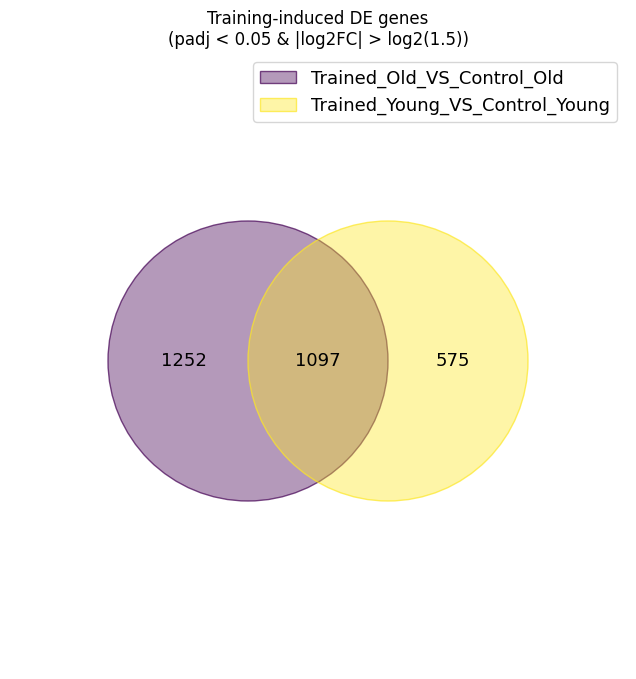

In [40]:
import numpy as np
import matplotlib.pyplot as plt
from venn import venn

# Contrasts of interest
contrasts = [
    "Trained_Old_VS_Control_Old",
    "Trained_Young_VS_Control_Young"
]
# Thresholds
padj_threshold = 0.05
log2fc_threshold = np.log2(1.5)

# Filter DE genes for these contrasts
de = concat[
    (concat["contrast"].isin(contrasts)) &
    (concat["padj"] < padj_threshold) &
    (concat["log2FoldChange"].abs() > log2fc_threshold)
]

# Build gene sets
gene_sets = {
    contrast: set(de.loc[de["contrast"] == contrast, "gene_name"])
    for contrast in contrasts
}

# Plot Venn diagram
plt.figure(figsize=(6, 6))
venn(gene_sets)
plt.title("Training-induced DE genes\n(padj < 0.05 & |log2FC| > log2(1.5))")
plt.show()


### Venn UP

<Figure size 600x600 with 0 Axes>

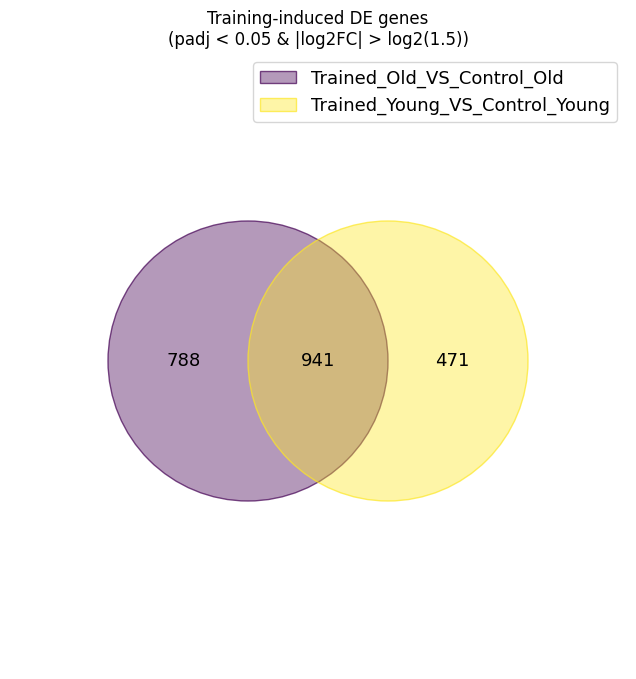

In [41]:
import numpy as np
import matplotlib.pyplot as plt
from venn import venn

# Thresholds
padj_threshold = 0.05
log2fc_threshold = np.log2(1.5)

# Contrasts of interest
contrasts = [
    "Trained_Old_VS_Control_Old",
    "Trained_Young_VS_Control_Young"
]

# Filter DE genes for these contrasts
de = concat[
    (concat["contrast"].isin(contrasts)) &
    (concat["padj"] < padj_threshold) &
    (concat["log2FoldChange"] > log2fc_threshold)
]

# Build gene sets
gene_sets = {
    contrast: set(de.loc[de["contrast"] == contrast, "gene_name"])
    for contrast in contrasts
}

# Plot Venn diagram
plt.figure(figsize=(6, 6))
venn(gene_sets)
plt.title("Training-induced DE genes\n(padj < 0.05 & |log2FC| > log2(1.5))")
plt.show()


<Figure size 600x600 with 0 Axes>

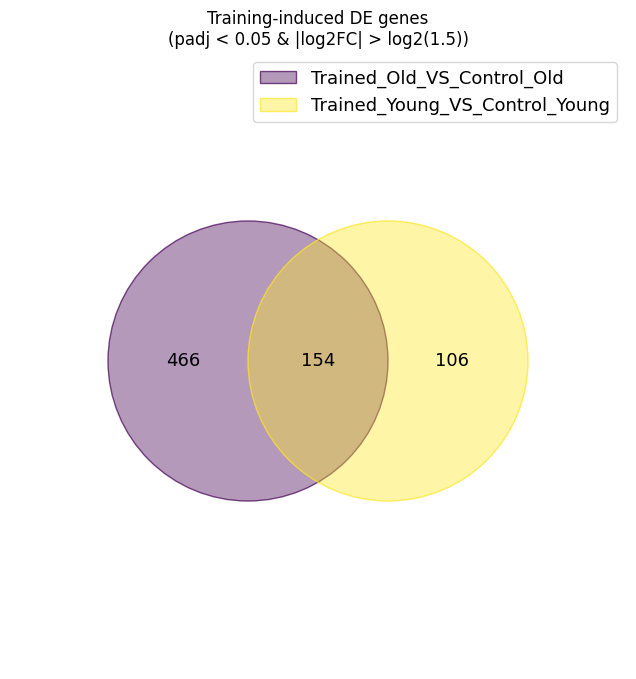

In [42]:
import numpy as np
import matplotlib.pyplot as plt
from venn import venn

# Thresholds
padj_threshold = 0.05
log2fc_threshold = np.log2(1.5)

# Contrasts of interest
contrasts = [
    "Trained_Old_VS_Control_Old",
    "Trained_Young_VS_Control_Young"
]

# Filter DE genes for these contrasts
de = concat[
    (concat["contrast"].isin(contrasts)) &
    (concat["padj"] < padj_threshold) &
    (concat["log2FoldChange"] < -log2fc_threshold)
]

# Build gene sets
gene_sets = {
    contrast: set(de.loc[de["contrast"] == contrast, "gene_name"])
    for contrast in contrasts
}

# Plot Venn diagram
plt.figure(figsize=(6, 6))
venn(gene_sets)
plt.title("Training-induced DE genes\n(padj < 0.05 & |log2FC| > log2(1.5))")
plt.show()